# Offline CV-RAG POC results

This notebook documents a verified offline computer-vision RAG run for construction incident management. The POC generates synthetic construction incident images, vectorizes them locally with CLIP, stores vectors in SQLite, retrieves visual incidents from text queries, and produces evidence-grounded response guidance without Azure AI Search or cloud inference.

Verified deployment context:

- Azure region: `southcentralus`
- VM: `Standard_NV6ads_A10_v5` Spot
- GPU exposed to guest: NVIDIA A10-4Q, 4 GB framebuffer
- Driver: NVIDIA GRID R570 `570.211.01`
- Runtime mode: `TRANSFORMERS_OFFLINE=1`, `HF_HUB_OFFLINE=1` for the documented evaluation pass
- Local index: SQLite file under `data/cv-rag/cv-rag.sqlite`
- Retrieval model: `openai/clip-vit-base-patch32`
- Answer generator for this documented run: deterministic evidence template fallback


## Architecture under test

The offline flow is intentionally simple and reproducible:

1. Generate synthetic incident records and construction-site images.
2. Embed each incident image with CLIP.
3. Embed each incident text record with the same CLIP text encoder.
4. Fuse image/text vectors so text queries can retrieve visual incidents from a small offline pack.
5. Store incident payloads and fused vectors in local SQLite.
6. Embed the field query locally and run cosine retrieval over the local vectors.
7. Build a grounded response from retrieved incident evidence and citations.

No Azure AI Search, remote vector database, or cloud LLM is used in the verified offline pass.


## What is indexed locally?

The local vector store prototype is a SQLite database with one table, `cv_incidents`:

| Column | Purpose |
| --- | --- |
| `incident_id` | Stable incident/case identifier used for citations. |
| `payload_json` | Full incident payload: title, category, severity, observation, recommended action, escalation rule, and image file. |
| `image_path` | Local path to the cached incident image. |
| `vector_json` | CLIP vector stored as JSON floats for the prototype. Production should replace this with `sqlite-vec`, USearch, or another ANN/local vector index. |

Each stored vector is a normalized fused vector: `0.65 * image_embedding + 0.35 * incident_text_embedding`. CLIP ViT-B/32 produces 512-dimensional image/text embeddings. The fusion keeps image retrieval central while making field text queries reliable against a small offline pack.


## Indexed synthetic incident pack

| incident_id | title | category | severity | image |
| --- | --- | --- | --- | --- |
| INC-001 | Basement wall water ingress | waterproofing | medium | assets/cv_rag_examples/images/inc_001_water_ingress.png |
| INC-002 | Concrete column honeycombing | concrete | high | assets/cv_rag_examples/images/inc_002_honeycombing.png |
| INC-003 | Rebar congestion at beam column joint | reinforcement | high | assets/cv_rag_examples/images/inc_003_rebar_congestion.png |
| INC-004 | MEP duct and ceiling clash | coordination | medium | assets/cv_rag_examples/images/inc_004_mep_clash.png |
| INC-005 | Unsafe open edge near scaffold | safety | critical | assets/cv_rag_examples/images/inc_005_open_edge.png |
| INC-006 | Crack near lift core wall | structure | medium | assets/cv_rag_examples/images/inc_006_lift_core_crack.png |

## Example images committed with the notebook

These synthetic images are intentionally simple visual proxies for the POC. The gallery now uses normal Markdown image links plus the executed preview cell below, avoiding HTML-in-table rendering issues in GitHub notebooks.

| Incident | Markdown image |
| --- | --- |
| INC-001 - Basement wall water ingress | ![INC-001 water ingress](assets/cv_rag_examples/images/inc_001_water_ingress.png) |
| INC-002 - Concrete column honeycombing | ![INC-002 honeycombing](assets/cv_rag_examples/images/inc_002_honeycombing.png) |
| INC-003 - Rebar congestion at beam-column joint | ![INC-003 rebar congestion](assets/cv_rag_examples/images/inc_003_rebar_congestion.png) |
| INC-004 - MEP duct and ceiling clash | ![INC-004 MEP clash](assets/cv_rag_examples/images/inc_004_mep_clash.png) |
| INC-005 - Unsafe open edge near scaffold | ![INC-005 open edge](assets/cv_rag_examples/images/inc_005_open_edge.png) |
| INC-006 - Crack near lift core wall | ![INC-006 lift core crack](assets/cv_rag_examples/images/inc_006_lift_core_crack.png) |


INC-001 - Basement wall water ingress


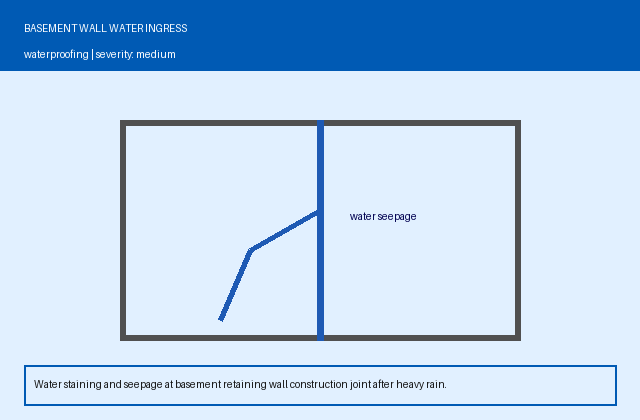

INC-002 - Concrete column honeycombing


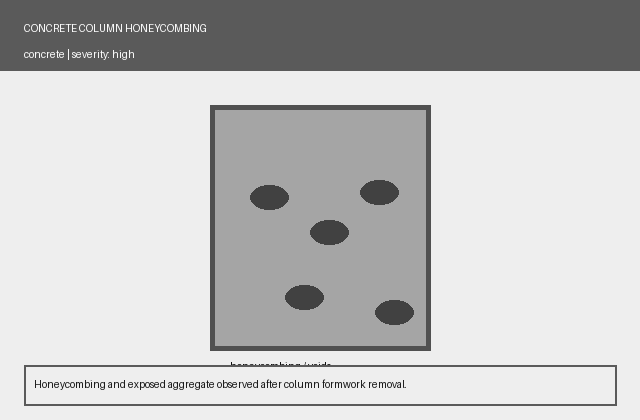

INC-003 - Rebar congestion at beam-column joint


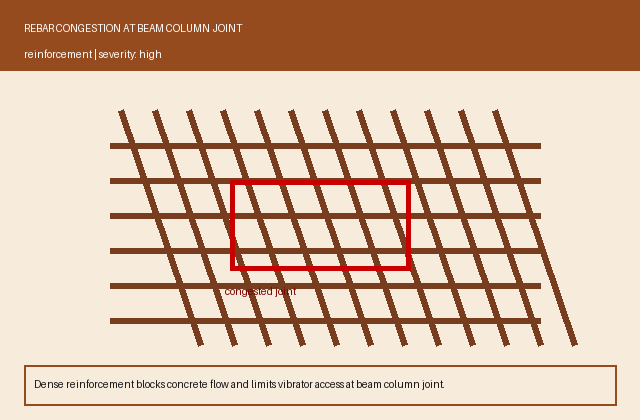

INC-004 - MEP duct and ceiling clash


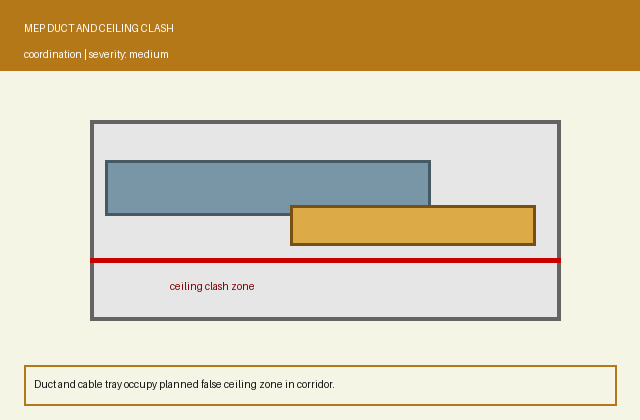

INC-005 - Unsafe open edge near scaffold


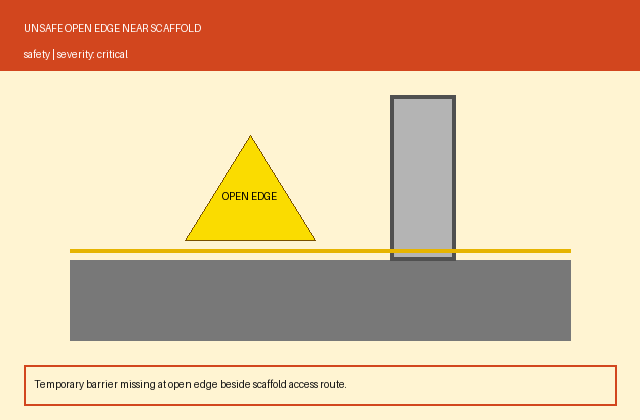

INC-006 - Crack near lift core wall


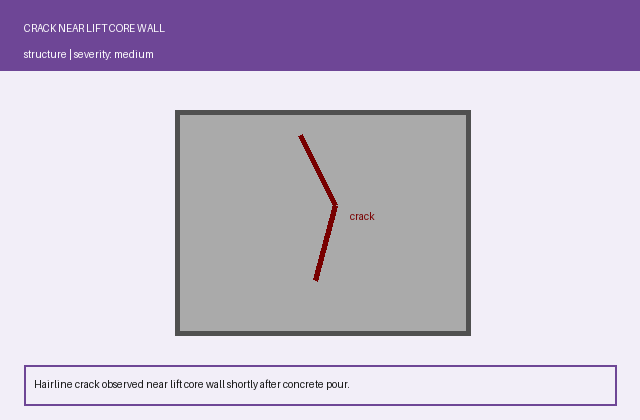

In [1]:
from IPython.display import Image, display

image_files = [
    ("INC-001", "Basement wall water ingress", "assets/cv_rag_examples/images/inc_001_water_ingress.png"),
    ("INC-002", "Concrete column honeycombing", "assets/cv_rag_examples/images/inc_002_honeycombing.png"),
    ("INC-003", "Rebar congestion at beam-column joint", "assets/cv_rag_examples/images/inc_003_rebar_congestion.png"),
    ("INC-004", "MEP duct and ceiling clash", "assets/cv_rag_examples/images/inc_004_mep_clash.png"),
    ("INC-005", "Unsafe open edge near scaffold", "assets/cv_rag_examples/images/inc_005_open_edge.png"),
    ("INC-006", "Crack near lift core wall", "assets/cv_rag_examples/images/inc_006_lift_core_crack.png"),
]

for incident_id, title, path in image_files:
    print(f"{incident_id} - {title}")
    display(Image(filename=path, width=320))


In [1]:
index_rows = [{'incident_id': 'INC-001', 'title': 'Basement wall water ingress', 'category': 'waterproofing', 'severity': 'medium', 'image': 'assets/cv_rag_examples/images/inc_001_water_ingress.png', 'indexed_text': 'Water staining and seepage at basement retaining wall construction joint after heavy rain. Action: inspect joint/waterstop, inject approved PU grout, monitor moisture.'}, {'incident_id': 'INC-002', 'title': 'Concrete column honeycombing', 'category': 'concrete', 'severity': 'high', 'image': 'assets/cv_rag_examples/images/inc_002_honeycombing.png', 'indexed_text': 'Honeycombing and exposed aggregate after column formwork removal. Action: stop covering works, notify QA/QC, assess depth/rebar exposure, repair with approved mortar.'}, {'incident_id': 'INC-003', 'title': 'Rebar congestion at beam column joint', 'category': 'reinforcement', 'severity': 'high', 'image': 'assets/cv_rag_examples/images/inc_003_rebar_congestion.png', 'indexed_text': 'Dense reinforcement blocks concrete flow and vibrator access. Action: pause pour, review workability/access, capture photos, obtain engineer direction.'}, {'incident_id': 'INC-004', 'title': 'MEP duct and ceiling clash', 'category': 'coordination', 'severity': 'medium', 'image': 'assets/cv_rag_examples/images/inc_004_mep_clash.png', 'indexed_text': 'Duct and cable tray occupy planned false ceiling zone. Action: raise BIM coordination issue, verify ceiling level, update shop drawing.'}, {'incident_id': 'INC-005', 'title': 'Unsafe open edge near scaffold', 'category': 'safety', 'severity': 'critical', 'image': 'assets/cv_rag_examples/images/inc_005_open_edge.png', 'indexed_text': 'Temporary barrier missing at open edge beside scaffold access. Action: stop access, install compliant guardrail/barricade, place warning signage.'}, {'incident_id': 'INC-006', 'title': 'Crack near lift core wall', 'category': 'structure', 'severity': 'medium', 'image': 'assets/cv_rag_examples/images/inc_006_lift_core_crack.png', 'indexed_text': 'Hairline crack near lift core wall after concrete pour. Action: measure crack width, check curing/temperature records, monitor, escalate if widening/leaking.'}]
query_results = [{'scenario': 'water ingress', 'query': 'A site photo shows water seepage and staining at a basement retaining wall construction joint after heavy rain.', 'expected': 'INC-001', 'top_hit': 'INC-001', 'matched': True, 'hits': [{'rank': 1, 'incident_id': 'INC-001', 'title': 'Basement wall water ingress', 'severity': 'medium', 'score': 0.5088}, {'rank': 2, 'incident_id': 'INC-002', 'title': 'Concrete column honeycombing', 'severity': 'high', 'score': 0.4471}, {'rank': 3, 'incident_id': 'INC-005', 'title': 'Unsafe open edge near scaffold', 'severity': 'critical', 'score': 0.4413}]}, {'scenario': 'concrete honeycombing', 'query': 'A site photo shows concrete honeycombing and exposed aggregate after column formwork removal.', 'expected': 'INC-002', 'top_hit': 'INC-002', 'matched': True, 'hits': [{'rank': 1, 'incident_id': 'INC-002', 'title': 'Concrete column honeycombing', 'severity': 'high', 'score': 0.5332}, {'rank': 2, 'incident_id': 'INC-005', 'title': 'Unsafe open edge near scaffold', 'severity': 'critical', 'score': 0.4559}, {'rank': 3, 'incident_id': 'INC-006', 'title': 'Crack near lift core wall', 'severity': 'medium', 'score': 0.4386}]}, {'scenario': 'rebar congestion', 'query': 'A site photo shows dense reinforcement at a beam column joint blocking concrete flow and vibrator access.', 'expected': 'INC-003', 'top_hit': 'INC-003', 'matched': True, 'hits': [{'rank': 1, 'incident_id': 'INC-003', 'title': 'Rebar congestion at beam column joint', 'severity': 'high', 'score': 0.5188}, {'rank': 2, 'incident_id': 'INC-002', 'title': 'Concrete column honeycombing', 'severity': 'high', 'score': 0.4977}, {'rank': 3, 'incident_id': 'INC-006', 'title': 'Crack near lift core wall', 'severity': 'medium', 'score': 0.4717}]}, {'scenario': 'MEP coordination clash', 'query': 'A site photo shows a duct and cable tray occupying the false ceiling zone in a corridor.', 'expected': 'INC-004', 'top_hit': 'INC-004', 'matched': True, 'hits': [{'rank': 1, 'incident_id': 'INC-004', 'title': 'MEP duct and ceiling clash', 'severity': 'medium', 'score': 0.5259}, {'rank': 2, 'incident_id': 'INC-005', 'title': 'Unsafe open edge near scaffold', 'severity': 'critical', 'score': 0.456}, {'rank': 3, 'incident_id': 'INC-006', 'title': 'Crack near lift core wall', 'severity': 'medium', 'score': 0.4217}]}, {'scenario': 'open edge safety', 'query': 'A site photo shows missing edge protection beside scaffold access.', 'expected': 'INC-005', 'top_hit': 'INC-005', 'matched': True, 'hits': [{'rank': 1, 'incident_id': 'INC-005', 'title': 'Unsafe open edge near scaffold', 'severity': 'critical', 'score': 0.5664}, {'rank': 2, 'incident_id': 'INC-002', 'title': 'Concrete column honeycombing', 'severity': 'high', 'score': 0.4797}, {'rank': 3, 'incident_id': 'INC-006', 'title': 'Crack near lift core wall', 'severity': 'medium', 'score': 0.4746}]}, {'scenario': 'lift core crack', 'query': 'A site photo shows a hairline crack near a lift core wall shortly after a concrete pour.', 'expected': 'INC-006', 'top_hit': 'INC-006', 'matched': True, 'hits': [{'rank': 1, 'incident_id': 'INC-006', 'title': 'Crack near lift core wall', 'severity': 'medium', 'score': 0.5439}, {'rank': 2, 'incident_id': 'INC-002', 'title': 'Concrete column honeycombing', 'severity': 'high', 'score': 0.4978}, {'rank': 3, 'incident_id': 'INC-005', 'title': 'Unsafe open edge near scaffold', 'severity': 'critical', 'score': 0.4647}]}]

top1_accuracy = sum(row["matched"] for row in query_results) / len(query_results)
print(f"Indexed incidents: {len(index_rows)}")
print(f"Example queries: {len(query_results)}")
print(f"Top-1 retrieval accuracy: {top1_accuracy:.1%}")

Indexed incidents: 6
Example queries: 6
Top-1 retrieval accuracy: 100.0%


## Example queries and top-1 result

The six queries below represent common construction-site incident categories. Each query was evaluated on the deployed GPU VM after the CLIP model was cached, then rerun with offline flags enabled.

| scenario | query | expected | top_hit | matched |
| --- | --- | --- | --- | --- |
| water ingress | A site photo shows water seepage and staining at a basement retaining wall construction joint after heavy rain. | INC-001 | INC-001 | True |
| concrete honeycombing | A site photo shows concrete honeycombing and exposed aggregate after column formwork removal. | INC-002 | INC-002 | True |
| rebar congestion | A site photo shows dense reinforcement at a beam column joint blocking concrete flow and vibrator access. | INC-003 | INC-003 | True |
| MEP coordination clash | A site photo shows a duct and cable tray occupying the false ceiling zone in a corridor. | INC-004 | INC-004 | True |
| open edge safety | A site photo shows missing edge protection beside scaffold access. | INC-005 | INC-005 | True |
| lift core crack | A site photo shows a hairline crack near a lift core wall shortly after a concrete pour. | INC-006 | INC-006 | True |

## Top-3 retrieval results per query

The top-3 table is useful because it shows both the correct match and the nearest confusable incidents. For example, honeycombing and rebar congestion are close because both are concrete/reinforcement quality issues, while safety/open-edge cases remain distinct.

| scenario | rank | incident_id | title | severity | score |
| --- | --- | --- | --- | --- | --- |
| water ingress | 1 | INC-001 | Basement wall water ingress | medium | 0.5088 |
| water ingress | 2 | INC-002 | Concrete column honeycombing | high | 0.4471 |
| water ingress | 3 | INC-005 | Unsafe open edge near scaffold | critical | 0.4413 |
| concrete honeycombing | 1 | INC-002 | Concrete column honeycombing | high | 0.5332 |
| concrete honeycombing | 2 | INC-005 | Unsafe open edge near scaffold | critical | 0.4559 |
| concrete honeycombing | 3 | INC-006 | Crack near lift core wall | medium | 0.4386 |
| rebar congestion | 1 | INC-003 | Rebar congestion at beam column joint | high | 0.5188 |
| rebar congestion | 2 | INC-002 | Concrete column honeycombing | high | 0.4977 |
| rebar congestion | 3 | INC-006 | Crack near lift core wall | medium | 0.4717 |
| MEP coordination clash | 1 | INC-004 | MEP duct and ceiling clash | medium | 0.5259 |
| MEP coordination clash | 2 | INC-005 | Unsafe open edge near scaffold | critical | 0.4560 |
| MEP coordination clash | 3 | INC-006 | Crack near lift core wall | medium | 0.4217 |
| open edge safety | 1 | INC-005 | Unsafe open edge near scaffold | critical | 0.5664 |
| open edge safety | 2 | INC-002 | Concrete column honeycombing | high | 0.4797 |
| open edge safety | 3 | INC-006 | Crack near lift core wall | medium | 0.4746 |
| lift core crack | 1 | INC-006 | Crack near lift core wall | medium | 0.5439 |
| lift core crack | 2 | INC-002 | Concrete column honeycombing | high | 0.4978 |
| lift core crack | 3 | INC-005 | Unsafe open edge near scaffold | critical | 0.4647 |

## Reproducible evaluation cell

Run this cell inside the deployed VM at `/opt/hybrid-rag-with-slm` to reproduce the result set. The model files must already be cached once before setting the offline flags.


In [ ]:
from pathlib import Path

from cv_rag.models import EvidenceTemplateGenerator, set_offline_mode
from cv_rag.pipeline import build_cv_index, build_prompt, search_cv_index

workspace = "data/cv-rag"
db_path = f"{workspace}/cv-rag.sqlite"
queries = [
    ("water ingress", "A site photo shows water seepage and staining at a basement retaining wall construction joint after heavy rain.", "INC-001"),
    ("concrete honeycombing", "A site photo shows concrete honeycombing and exposed aggregate after column formwork removal.", "INC-002"),
    ("rebar congestion", "A site photo shows dense reinforcement at a beam column joint blocking concrete flow and vibrator access.", "INC-003"),
    ("MEP coordination clash", "A site photo shows a duct and cable tray occupying the false ceiling zone in a corridor.", "INC-004"),
    ("open edge safety", "A site photo shows missing edge protection beside scaffold access.", "INC-005"),
    ("lift core crack", "A site photo shows a hairline crack near a lift core wall shortly after a concrete pour.", "INC-006"),
]

Path(workspace).mkdir(parents=True, exist_ok=True)
Path(db_path).unlink(missing_ok=True)
index_count = build_cv_index(workspace, db_path, device="cuda")
set_offline_mode()
generator = EvidenceTemplateGenerator()

rows = []
for scenario, query, expected in queries:
    hits = search_cv_index(query, db_path, device="cuda", top_k=3)
    answer = generator.generate(build_prompt(query, hits))
    rows.append({
        "scenario": scenario,
        "expected": expected,
        "top_hit": hits[0].incident.incident_id,
        "score": round(hits[0].score, 4),
        "matched": hits[0].incident.incident_id == expected,
        "top3": [(hit.incident.incident_id, round(hit.score, 4)) for hit in hits],
        "answer": answer,
    })

rows

## Representative answer: concrete honeycombing

The documented offline run retrieved the correct incident at rank 1 for a honeycombing query. The answer below is generated only from local incident evidence.


In [2]:
honeycombing_answer = 'Offline CV-RAG answer from local image vectors and incident records.\nQuestion: A site photo shows concrete honeycombing after formwork removal. What should be done?\n\nMost relevant visual incidents:\n[INC-002] score=0.533; title=Concrete column honeycombing; severity=high; image=data/cv-rag/images/inc_002_honeycombing.png; observation=Honeycombing and exposed aggregate observed after column formwork removal.; action=Stop covering works, notify QA/QC, remove loose concrete, assess depth and rebar exposure, and repair with approved mortar.; escalation=Escalate to structural engineer before any concealment or load transfer work.\n[INC-005] score=0.456; title=Unsafe open edge near scaffold; severity=critical; image=data/cv-rag/images/inc_005_open_edge.png; observation=Temporary barrier missing at open edge beside scaffold access route.; action=Stop access, install compliant guardrail or barricade, place warning signage, and record corrective action.; escalation=Escalate immediately to safety officer and site supervisor.\n[INC-006] score=0.439; title=Crack near lift core wall; severity=medium; image=data/cv-rag/images/inc_006_lift_core_crack.png; observation=Hairline crack observed near lift core wall shortly after concrete pour.; action=Measure crack width, check curing and temperature records, inspect water ingress, and start monitoring log.; escalation=Escalate to structural engineer if crack widens, leaks, or aligns with critical load path.\n\nRecommended response:\n1. Compare the current site photo with the cited incident image and observation.\n2. Apply only the corrective action that matches the field condition.\n3. Escalate critical safety or structural issues before work continues.\n\nOffline limitation: no cloud search, no remote standards lookup, and no supervisor approval automation.'

print(honeycombing_answer)

Offline CV-RAG answer from local image vectors and incident records.
Question: A site photo shows concrete honeycombing after formwork removal. What should be done?

Most relevant visual incidents:
[INC-002] score=0.533; title=Concrete column honeycombing; severity=high; image=data/cv-rag/images/inc_002_honeycombing.png; observation=Honeycombing and exposed aggregate observed after column formwork removal.; action=Stop covering works, notify QA/QC, remove loose concrete, assess depth and rebar exposure, and repair with approved mortar.; escalation=Escalate to structural engineer before any concealment or load transfer work.
[INC-005] score=0.456; title=Unsafe open edge near scaffold; severity=critical; image=data/cv-rag/images/inc_005_open_edge.png; observation=Temporary barrier missing at open edge beside scaffold access route.; action=Stop access, install compliant guardrail or barricade, place warning signage, and record corrective action.; escalation=Escalate immediately to safety 

## Interpretation

- The POC demonstrates the full offline path: local synthetic image pack, local CV vectorization, local SQLite vector store, local retrieval, and local grounded answer drafting.
- The notebook now shows exactly what entered the local vector store: image path, incident payload, action guidance, escalation rule, and fused CLIP vector.
- The top-3 result table is more informative than top-1 alone because it exposes nearest-neighbor behavior and likely confusions.
- The A10-4Q VM has 4 GB GPU memory, which is appropriate for CLIP retrieval and constrained-device simulation. Phi-4 generation should be tested with ONNX/int4 CPU/mobile runtime or a larger GPU slice if full local neural generation is required.
- The result set is synthetic and should be replaced with real site images, incident records, acceptance criteria, and safety escalation rules for production evaluation.
